# **Customer Cohort & Customer Lifecycle Retention Analysis**

This notebook performs exploratory data analysis focusing on monthly customer retention cohorts and active customer lifecycle flows for the UK-based online retail dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimpy import skim

## **1. Data Loading & Cleaning**

In [2]:
print("Loading data...")
df = pd.read_csv('online_retail_II.csv')

print("Cleaning data...")
# Drop duplicates
df.drop_duplicates(inplace=True, ignore_index=True)

# Remove invalid quantities and prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Fill missing Customer IDs via invoice mapping
mapping_df = df.dropna(subset=['Customer ID']).drop_duplicates(subset=['Invoice'])
invoice_to_customer = mapping_df.set_index('Invoice')['Customer ID']
df['Customer ID'] = df['Customer ID'].fillna(df['Invoice'].map(invoice_to_customer))
df['Customer ID'] = df['Customer ID'].fillna('Guest_' + df['Invoice'])

# Format datetime and calculate revenue
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%Y-%m-%d %H:%M:%S')
df['revenue'] = df['Quantity'] * df['Price']
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

df.head()

Loading data...
Cleaning data...


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue,InvoiceMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


## **2. Monthly Cohort Retention Analysis**

In [3]:
# Assign cohort month to each customer
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceMonth'].transform('min')

# Calculate the index difference (CohortIndex)
df['CohortIndex'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)

# Aggregate unique customers by cohort and index
cohort_group = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_matrix = cohort_group.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# Compute retention rate in percentage
cohort_sizes = cohort_matrix.iloc[:, 0]
retention = cohort_matrix.divide(cohort_sizes, axis=0) * 100
retention.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,29.955556,28.355556,36.088889,32.266667,30.488889,32.000000,29.066667,28.533333,30.755556,...,25.688889,22.311111,25.688889,24.000000,22.044444,21.688889,26.755556,25.866667,34.577778,16.711111
2010-01,100.0,16.561845,24.947589,24.528302,21.174004,24.109015,20.754717,18.448637,22.431866,25.576520,...,12.159329,18.867925,15.932914,14.884696,15.723270,19.496855,15.513627,19.706499,4.612159,NaN
2010-02,100.0,18.855932,17.796610,23.093220,19.491525,15.889831,15.254237,22.669492,20.127119,21.822034,...,15.889831,12.711864,12.923729,11.440678,18.220339,18.220339,12.923729,4.661017,NaN,NaN
2010-03,100.0,14.000000,17.000000,17.833333,17.166667,15.000000,18.166667,22.333333,20.333333,8.000000,...,12.500000,12.833333,11.500000,13.000000,14.833333,15.666667,5.833333,NaN,NaN,NaN
2010-04,100.0,13.348946,13.348946,11.241218,12.646370,15.456674,18.969555,18.032787,7.259953,7.494145,...,10.772834,9.601874,10.304450,12.412178,15.456674,3.981265,NaN,NaN,NaN,NaN


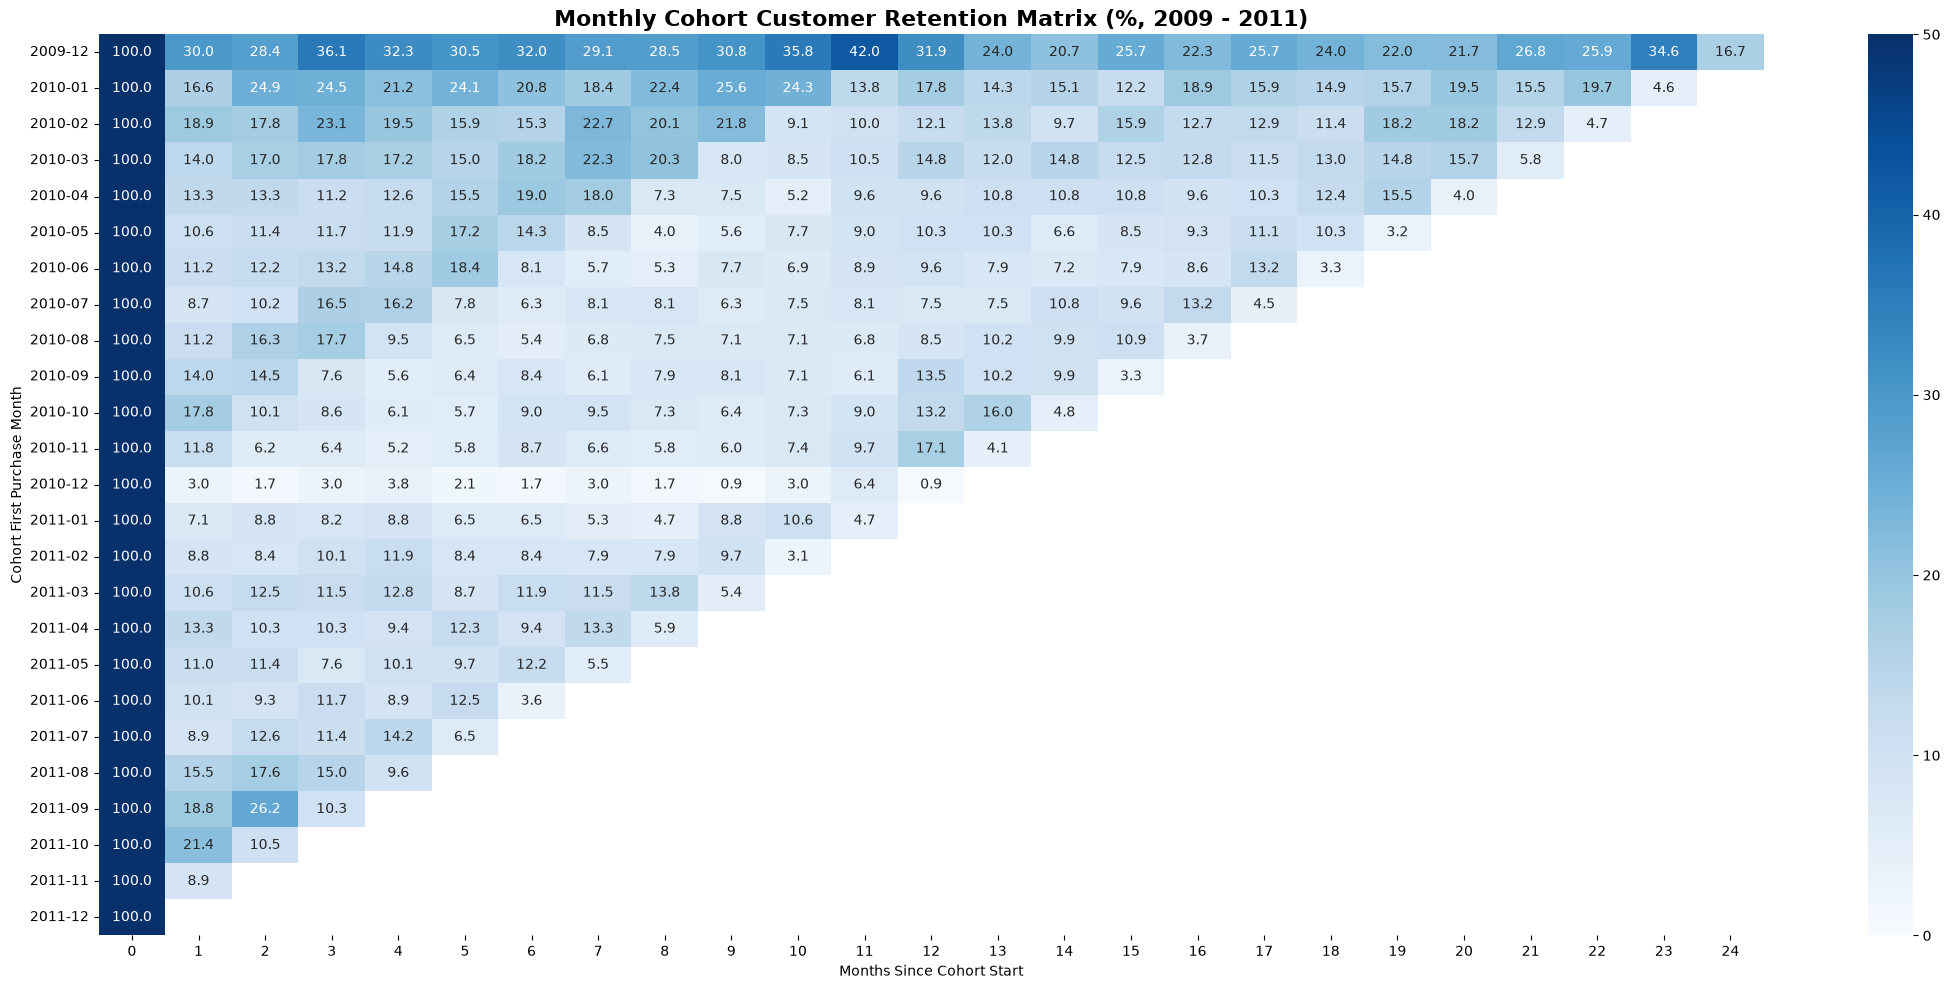

In [4]:
# Plot Cohort Retention Heatmap
plt.figure(figsize=(22, 10))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='Blues', vmin=0, vmax=50)
plt.title('Monthly Cohort Customer Retention Matrix (%, 2009 - 2011)', fontsize=16, fontweight='bold')
plt.ylabel('Cohort First Purchase Month')
plt.xlabel('Months Since Cohort Start')
plt.tight_layout()
plt.show()

## **3. Monthly Customer Lifecycle Analysis (Active vs. Churned)**

In [5]:
months = sorted(df['InvoiceMonth'].unique())
lifecycle_records = []
seen_before = set()

for i, m in enumerate(months):
    current_buyers = set(df[df['InvoiceMonth'] == m]['Customer ID'].unique())
    totalrevenue = df[df['InvoiceMonth'] == m]['revenue'].sum()
    if i == 0:
        new_cust = len(current_buyers)
        retained_cust = 0
        resurrected_cust = 0
        churned_cust = 0
        seen_before.update(current_buyers)
    else:
        prev_buyers = set(df[df['InvoiceMonth'] == months[i-1]]['Customer ID'].unique())
        
        new_buyers = current_buyers - seen_before
        new_cust = len(new_buyers)
        
        retained_buyers = current_buyers & prev_buyers
        retained_cust = len(retained_buyers)
        
        resurrected_buyers = (current_buyers & seen_before) - prev_buyers
        resurrected_cust = len(resurrected_buyers)
        
        churned_buyers = prev_buyers - current_buyers
        churned_cust = len(churned_buyers)
        
        seen_before.update(current_buyers)
        
    lifecycle_records.append({
        'Month': str(m),
        'New': new_cust,
        'Retained': retained_cust,
        'Resurrected': resurrected_cust,
        'Churned': churned_cust,
        'TotalRevenue': totalrevenue
    })

lifecycle_df = pd.DataFrame(lifecycle_records).set_index('Month')
lifecycle_df.head(20)

,New,Retained,Resurrected,Churned,TotalRevenue
Month,,,,,
2009-12,1125,0,0,0,822483.950
2010-01,477,337,0,788,651155.112
2010-02,472,262,136,552,551878.296
2010-03,600,314,300,556,830915.261
2010-04,427,378,270,836,678875.252
2010-05,377,345,367,730,657705.500
2010-06,418,368,403,721,749537.310
2010-07,334,392,350,797,648810.270
2010-08,294,351,398,725,695251.910


In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Khởi tạo biểu đồ có 2 trục Y (secondary_y=True)
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Danh sách các nhóm Active để chạy vòng lặp
categories = ['Retained', 'Resurrected', 'New']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# 2. Thêm các cột chồng phía trên trục 0 (Active groups)
for cat, col in zip(categories, colors):
    fig.add_trace(
        go.Bar(
            x=lifecycle_df.index,
            y=lifecycle_df[cat],
            name=cat,
            marker_color=col,
            # Cấu hình tooltip hiển thị định dạng số có dấu phẩy phân cách
            hovertemplate=f"{cat}: %{{y:,}}<extra></extra>"
        ),
        secondary_y=False
    )

# 3. Thêm cột Churned phía dưới trục 0 (Giá trị âm)
fig.add_trace(
        go.Bar(
            x=lifecycle_df.index,
            y=-lifecycle_df['Churned'],  # Biểu diễn số âm để cột chúc xuống
            name='Churned',
            marker_color='#d62728',
            opacity=0.8,
            # Dùng customdata để ép hiển thị số DƯƠNG trên tooltip cho đẹp
            customdata=lifecycle_df['Churned'],
            hovertemplate="Churned: %{customdata:,}<extra></extra>"
        ),
        secondary_y=False
    )

# 4. Thêm đường Line cho Total Revenue ở trục Y thứ hai (bên phải)
fig.add_trace(
    go.Scatter(
        x=lifecycle_df.index,
        y=lifecycle_df['TotalRevenue'],
        name='Total Revenue',
        mode='lines+markers',
        line=dict(color='#9467bd', width=3),
        marker=dict(size=8),
        hovertemplate="Total Revenue: $%{y:,}<extra></extra>"
    ),
    secondary_y=True
)

# 5. Cấu hình giao diện và đồng bộ trục tọa độ
# Tính toán để ép trục Y thứ hai (Revenue) có đường gốc số 0 trùng khớp với trục Y thứ nhất
y1_max = lifecycle_df[['Retained', 'Resurrected', 'New']].sum(axis=1).max()
y1_min = -lifecycle_df['Churned'].max()
ratio = y1_max / abs(y1_min)

y2_max = lifecycle_df['TotalRevenue'].max() * 1.1 # Cho rộng hơn đỉnh 10%
y2_min = -y2_max / ratio

fig.update_layout(
    # 'relative' giúp tự động chồng các số dương lên trên và số âm xuống dưới
    barmode='relative', 
    title=dict(
        text='Monthly Customer Lifecycle Flow & Total Revenue Trend',
        font=dict(size=16, weight='bold')
    ),
    xaxis=dict(title='Month', tickangle=45),
    yaxis=dict(title='Number of Customers', range=[y1_min * 1.1, y1_max * 1.1]),
    yaxis2=dict(title='Total Revenue ($)', range=[y2_min, y2_max]),
    
    # Hovermode 'x unified' gom toàn bộ thông tin của tháng đó vào 1 ô duy nhất khi rê chuột
    hovermode='x unified', 
    legend=dict(x=1.08, y=1, xanchor='left', yanchor='top'),
    width=1200,
    height=600,
    plot_bgcolor='white'
)

# Thêm đường kẻ đậm tại vị trí số 0
fig.update_yaxes(zeroline=True, zerolinecolor='black', zerolinewidth=1)

# Hiển thị biểu đồ (Nếu dùng Jupyter Notebook/Lab hoặc xuất ra file html)
fig.show()

# **Executive Conclusion & Strategy Proposals**

### 🧠 Strategic Insights from Retention & Lifecycle Analysis

1. **The Month-1 Drop (Cohort Retention)**:
   - Across almost all monthly cohorts, there is a sharp and immediate drop in retention in the first month following acquisition (retaining only 14% to 30% of customers). This indicates a high rate of one-time buyers.
   - However, once customers survive the first 3 months, their retention rates stabilize into a loyal baseline of 15% - 25% for up to 24 months.
   - *Strategic Action*: The customer journey needs immediate post-purchase intervention (e.g., custom onboarding, post-purchase coupon, automated follow-up emails) within the first 30 days to improve Month-1 retention.

2. **Growth Dynamics (Lifecycle Breakdown)**:
   - The active customer base is heavily dependent on **New Customers** and **Resurrected Customers** rather than a compounding base of **Retained Customers**.
   - Seasonal periods like October–November show high peaks in resurrected customers, proving that dormant accounts reactivate naturally during the holiday shopping season.
   - *Strategic Action*: Run targeted re-engagement campaigns in August-September to capture this seasonal demand early, converting dormant users back to active status.

---

### 📝 Proposal Quote

> **"Customer retention is the ultimate driver of sustainable retail growth. By converting 10% of our high-value one-time buyers into repeat wholesalers, we can increase our monthly revenue baseline by up to 25% without additional customer acquisition costs."**

* **Proposal 1: Immediate First-Purchase Follow-Up**
  - Implement a 3-part automated email welcome series offering special discounts for secondary purchases within 30 days.
* **Proposal 2: Tiered Wholesaler Loyalty Program**
  - Introduce volume-based pricing and VIP support tiers for customers with consecutive active months to encourage high-frequency purchasing.
* **Proposal 3: Reactivation Promotions for High-Value Churned Accounts**
  - Use past purchasing history to send personalized recommendations and reactivation discounts to customers who haven't ordered in 60+ days.